In [1]:
import xpress as xp
import numpy as np 
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
def change_name(name):
    n = len(name)
    a = name[:(n-7)//2]
    #print(a)
    b = name[(n-7)//2 + 2:]
    #print(b)
    c = name[:(n-7)//2 +5]
    d = name[(n-7)//2 +5+2:]
    if '(UG)' in a:
        return a
    elif '(UG)' in b:
        return b
    elif '(UG)' in c:
        return c
    elif '(UG)' in c:
        return d
    else:
        split = name.split(',')
        a = split[0]
        b = split[1]
        if '(UG)' in a:
            return a
        elif '(UG)' in b:
            return b
        else:
            return "Error"
departments_needed = ['School of Mathematics','School of Philosophy, Psychology and Language Sciences','School of Economics','School of Informatics',
                      # 'School of Physics and Astronomy',
                      'Business School']
collections_needed = ['Economics Course Options for Joint Programmes Year 3 (A)',
       'Economics Course Options Year 3 (joint programmes)',
       'Economics and Maths Dissertation',
       'Economics Course Options Year 4 (joint programmes)',
       'Topics in Microeconomics', 'Essentials of Econometrics',#'MathPhy : Mathematics Projects',
       # 'MathsPhysics : Y4 Physics Projects',
       # 'Undergraduate (School of Physics and Astronomy) Level 10 and 11 courses',
       # 'Electromagnetism and Relativity',
       # 'MathsPhysics : Y3 physics choice',
       # 'Undergraduate (School of Physics and Astronomy) Level 9 and 10  courses',
       'MathsBusiness : Y4 Projects',
       '2024-25: UTMATHB : Y4/5 : Approved Outside Courses',
       'ROU_H_UT International Business 4_10',
       'Strategic Management',
       '2024-25: UTMATHB : Y3 options : Business options',
       'Informatics Hons 3rd Year Group Project and Large Practical',
       'Informatics Hons 3rd Year AI Courses',
       'Informatics Hons 3rd Year Joint Degree CS Courses',
       'Informatics - Professional Issues',
       'Honours Project (Informatics)',
       'Informatics Hons 4th Year Courses',
        'Year 3 Philosophy - History of Philosophy',
       'Practical Philosophy', 'Theoretical Philosophy',
       'Philosophy Honours Year 4']
programmes_needed = ['Mathematics and Business BSc (Hons)',
                     # 'Mathematics and Physics (BSc Hons)',
                     'Economics and Mathematics (MA Hons)','Computer Science and Mathematics (BSc Hons)',
              'Philosophy and Mathematics (MA Hons)']
courses_df = pd.read_csv("2024-5 Event Module Room.csv")
courses_df = courses_df[courses_df["Module Department"].isin(departments_needed)]
courses_df = courses_df[courses_df["Event Type"]=="Lecture"]
programme_df = pd.read_csv('2024-5 DPT Data.csv',encoding = "latin1")

programme_df = programme_df[programme_df["Programme Year"].isin([3])]
programme_df = programme_df[programme_df["Programme Name"].isin(programmes_needed)]
programme_df = programme_df[programme_df["Collection Name"].isin(collections_needed)]

ug_indices = courses_df[
    (courses_df["Module Department"]=="School of Informatics") & 
    (courses_df['Module Name'].str.contains('\(UG\)', na=False))
].index

# Apply the change_name function to those specific rows
courses_df.loc[ug_indices, 'Module Name'] = courses_df.loc[ug_indices, 'Module Name'].apply(change_name)
#programme_df = programme_df[programme_df['Collection Reg Group']!="Physics 3 A"]

In [3]:
# Year 3
#Informatics 
condition_inf_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme School Name'] == 'School of Informatics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_inf_A3, 'Collection Reg Group'] = 'School of Informatics 3 A'

#Economics
condition_eco_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme School Name'] == 'School of Economics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_eco_A3, 'Collection Reg Group'] = 'Economics 3 A'

#Philosophy
condition_phi_B3 = (
    (programme_df['Collection Reg Group'] == 'B') & 
    (programme_df['Programme School Name'] == 'School of Philosophy, Psychology and Language Sciences') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_phi_B3, 'Collection Reg Group'] = 'Philosophy 3 B'

#Business
condition_bus_B3 = (
    (programme_df['Collection Reg Group'] == 'B') & 
    (programme_df['Programme Name'] == 'Mathematics and Business BSc (Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bus_B3, 'Collection Reg Group'] = 'Business 3 B'

#Physics
condition_phy_A3 = (
    (programme_df['Collection Reg Group'] == 'A') & 
    (programme_df['Programme Name'] == 'Mathematics and Physics (BSc Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_phy_A3, 'Collection Reg Group'] = 'Physics 3 A'




In [4]:
#Physics
condition_bounds_phy_A3 = (
    (programme_df['Collection Reg Group'] == 'Physics 3 A') & 
    (programme_df['Programme Name'] == 'Mathematics and Physics (BSc Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_phy_A3, 'Collection Group Min'] = 20.0
programme_df.loc[condition_bounds_phy_A3, 'Collection Group Max'] = 40.0

#Business
condition_bounds_bus_B3 = (
    (programme_df['Collection Reg Group'] == 'Business 3 B') & 
    (programme_df['Programme Name'] == 'Mathematics and Business BSc (Hons)') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_bus_B3, 'Collection Group Min'] = 0.0
programme_df.loc[condition_bounds_bus_B3, 'Collection Group Max'] = 60.0

#Philosophy
condition_bounds_phi_B3 = (
    (programme_df['Collection Reg Group'] == 'Philosophy 3 B') & 
    (programme_df['Programme School Name'] == 'School of Philosophy, Psychology and Language Sciences') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_phi_B3, 'Collection Group Min'] = 40.0
programme_df.loc[condition_bounds_phi_B3, 'Collection Group Max'] = 80.0

#Economics
condition_bounds_eco_A3 = (
    (programme_df['Collection Reg Group'] == 'Economics 3 A') & 
    (programme_df['Programme School Name'] == 'School of Economics') & 
    (programme_df['Programme Year'] == 3)
)
programme_df.loc[condition_bounds_eco_A3, 'Collection Group Min'] = 0.0
programme_df.loc[condition_bounds_eco_A3, 'Collection Group Max'] = 20.0



In [5]:
def extract_programme_structure(programme_df):
    """
    Extract programme-specific information including collections and regression groups
    Returns a dictionary structure with collections and regression groups as dictionaries
    """
    # Get unique programmes
    programmes = programme_df['Programme Name'].unique().tolist()
    
    programme_data = {}
    
    for programme in programmes:
        prog_data = programme_df[programme_df['Programme Name'] == programme]
        
        # Get compulsory and optional courses for this programme
        compulsory_courses = prog_data[
            prog_data['Compulsory/Optional'] == 'Compulsory'
        ]['Course Name'].unique().tolist()
        
        optional_courses = prog_data[
            prog_data['Compulsory/Optional'] == 'Optional'
        ]['Course Name'].unique().tolist()
        
        # Get all courses for this programme
        all_courses = prog_data['Course Name'].unique().tolist()
        
        # Get collection information - store as dictionary
        collections = {}
        for _, row in prog_data.iterrows():
            collection_code = row.get('Collection Code')
            if pd.notna(collection_code) and collection_code != '':
                if collection_code not in collections:
                    collections[collection_code] = {
                        'name': row.get('Collection Name', ''),
                        'min_value': row.get('Collection Min Value', 0),
                        'max_value': row.get('Collection Max Value', 999),
                        'reg_group': row.get('Collection Reg Group', ''),
                        'courses': []
                    }
                # Add course to collection if not already there
                if row['Course Name'] not in collections[collection_code]['courses']:
                    collections[collection_code]['courses'].append(row['Course Name'])
        
        # Get regression group information - store as dictionary
        regression_groups = {}
        for _, row in prog_data.iterrows():
            reg_group = row.get('Collection Reg Group')
            if pd.notna(reg_group) and reg_group != '':
                if reg_group not in regression_groups:
                    regression_groups[reg_group] = {
                        'min_value': row.get('Collection Group Min', 0),
                        'max_value': row.get('Collection Group Max', 999),
                        'collections': []
                    }
                # Add collection to regression group if not already there
                collection_code = row.get('Collection Code')
                if pd.notna(collection_code) and collection_code != '':
                    if collection_code not in regression_groups[reg_group]['collections']:
                        regression_groups[reg_group]['collections'].append(collection_code)
        
        programme_data[programme] = {
            'compulsory_courses': compulsory_courses,
            'optional_courses': optional_courses,
            'all_courses': all_courses,
            'collections': collections,
            'regression_groups': regression_groups
        }
    
    return programme_data
programme_data = extract_programme_structure(programme_df)
#programme_data

In [6]:


def extract_timetable_info(courses_df, programmes_data):
    """
    Extract v parameter with dynamic duration per course
    """
    # Filter for all relevant courses
    all_relevant_courses = {"G1","G2","G3","G4",'G5','G6','G7','G8','O1','O2','O3','O4'}
    
    for programme in programmes_data:
        all_relevant_courses.update(programmes_data[programme]['compulsory_courses'])
        all_relevant_courses.update(programmes_data[programme]['optional_courses'])
    
    # Filter timetable data for relevant courses
    relevant_schedule = courses_df[courses_df['Module Name'].isin(all_relevant_courses)].copy()
    
    # Parse timeslot (format: "Monday 10:00")
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    # Parse weeks (format like "1-11,13-24")
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to integers
    day_map = {
        'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 
        'Friday': 5, 'Saturday': 6, 'Sunday': 7,
        'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7
    }
    
    # Create v parameter dictionary
    v = {}
    
    # For each course, build a dictionary of its scheduled events with durations
    for course in relevant_schedule['Module Name'].unique():
        course_schedule = relevant_schedule[relevant_schedule['Module Name'] == course]
        
        for _, row in course_schedule.iterrows():
            # Get timeslot
            day, start_hour = parse_timeslot(row['Timeslot'])
            if day is None:
                continue
                
            day_num = day_map.get(day, 0)
            if day_num == 0:
                print(f"Warning: Unknown day format: {day}")
                continue
            
            # Get duration from the Duration column
            duration = row['Duration (minutes)']
            if pd.isna(duration):
                # Fallback: use default based on event type
                event_type = row['Event Type']
                default_durations = {
                    'Lecture': 60,
                    'Workshop': 60,
                    'Tutorial': 60,
                    'Lab': 120,
                    'Seminar': 60
                }
                duration = default_durations.get(event_type, 60)
            
            # Calculate end hour (assuming duration is in minutes)
            # If duration is 60, end_hour = start_hour + 1
            # If duration is 90, end_hour = start_hour + 1.5 (we'll handle half-hours)
            # For simplicity, we'll treat hour slots as discrete and mark all hours covered
            duration_hours = duration / 60
            end_hour_float = start_hour + duration_hours
            
            # Determine which hour slots this event occupies
            # For integer hours, we can use integer hours
            occupied_hours = []
            current_hour = start_hour
            remaining_duration = duration
            
            while remaining_duration > 0:
                occupied_hours.append(current_hour)
                remaining_duration -= 60
                current_hour += 1
            
            # Alternative: if you want to handle half-hour slots more precisely
            # occupied_hours = [h for h in range(start_hour, start_hour + int(np.ceil(duration_hours)))]
            
            # Parse weeks
            weeks = parse_weeks(row['Weeks'])
            
            # Determine semester
            semester = row['Semester']
            if semester not in [1, 2]:
                # If semester is not 1 or 2, try to infer from weeks
                if weeks and max(weeks) <= 26:
                    semester = 1
                elif weeks and min(weeks) >= 27:
                    semester = 2
                else:
                    semester = 1
            
            campus = row['Campus']
            
            # For each week the course runs
            for week in weeks:
                # For each hour slot the course occupies
                for hour in occupied_hours:
                    # For each programme that includes this course
                    for programme in programmes_data:
                        if course in programmes_data[programme]['all_courses']:
                            v[(course, day_num, hour, week, programme, campus)] = 1
                        else:
                            v[(course, day_num, hour, week, programme, campus)] = 0
    
    return v
programmes_data = extract_programme_structure(programme_df)
#extract_timetable_info(courses_df, programmes_data)

In [7]:
def extract_days_hours_from_v(v):
    """
    Extract unique days and hours from v dictionary
    """
    if not v:
        # If v is empty, use default days and hours
        return [1, 2, 3, 4, 5], list(range(9, 17))  # Monday-Friday, 9am-5pm
    
    days = sorted(list(set([key[1] for key in v.keys()])))
    hours = sorted(list(set([key[2] for key in v.keys()])))
    
    # If no days/hours found, use defaults
    if not days:
        days = [1, 2, 3, 4, 5]
    if not hours:
        hours = list(range(9, 17))
    
    return days, hours

# Add this to your extract_all_parameters function
def extract_all_parameters(courses_df, programme_df):
    """
    Complete extraction including days and hours
    """
    
    # Step 1: Define Maths courses
    gateway_courses = ["G1","G2","G3","G4",'G5','G6','G7','G8']
    optional_courses = ['O1','O2','O3','O4']
    
    # Step 2: Extract programme structure
    programme_data = extract_programme_structure(programme_df)
    programmes = list(programme_data.keys())
    
    # Step 3: Extract timetable info
    v = extract_timetable_info(courses_df, programme_data)
    
    # Step 4: Extract days and hours from v
    #days, hours = extract_days_hours_from_v(v)
    days = [1,2,3,4,5]
    hours = [9,10,11,12,13,14,15,16,17]

    weeks = list(range(1, 53))  # E = {1, ..., 52}
    weeks_sem1 = list(range(9, 19))  # E_1 = {9, ..., 19}
    weeks_sem2 = list(range(26, 37))  # E_2 = {26, ..., 37}

    campuses = courses_df['Campus'].dropna().unique().tolist()
    
    # Build the complete parameter set
    parameters = {
        # Sets
        'G': gateway_courses,
        'O': optional_courses,
        'S': [1, 2],  # Semesters
        'D': days,    # Days extracted from timetable
        'H': hours,   # Hours extracted from timetable
        'W': [1, 2],  # Week parity
        'Q': programmes,
        'E': weeks,           # All weeks
        'E1': weeks_sem1,     # Semester 1 weeks
        'E2': weeks_sem2,     # Semester 2 weeks
        'K': campuses,        # Campuses
        # Parameters
        'R_g_L': 3,  # Fixed for gateway
        'R_g_W': 1,  # Fixed for gateway
        'R_g_F': 1,  # Fixed for gateway
        'R_o_L': 3,  # Fixed for optional
        'R_o_W': 1,  # Fixed for optional
        'C_g': 4,    # 4 gateway courses per semester
        'C_o': 2,    # 2 optional courses per semester
        'n_q': {programme: 40 for programme in programmes},  # 40 credits outside Maths
        'n_co': {},  # Credits for each course
        'v': v,
        
        # Programme-specific data
        'programme_data': programme_data,
        
        # Collection and regression groups
        'min_CL': {},
        'max_CL': {},
        'min_CR': {},
        'max_CR': {},
        'SC_cl': {},
        'SCL_cr': {}
    }
    
    # Extract credits (same as before)
    all_courses = set(gateway_courses + optional_courses)
    for programme in programmes:
        all_courses.update(programme_data[programme]['all_courses'])
    
    for course in all_courses:
        credit_info = programme_df[programme_df['Course Name'] == course]['SCQF Credits']
        if len(credit_info) > 0:
            credit_value = credit_info.iloc[0]
            if isinstance(credit_value, str):
                import re
                numbers = re.findall(r'\d+\.?\d*', credit_value)
                if numbers:
                    parameters['n_co'][course] = float(numbers[0])
                else:
                    parameters['n_co'][course] = 20.0
            else:
                parameters['n_co'][course] = float(credit_value)
        else:
            parameters['n_co'][course] = 20.0
    
    # Extract collection information
    for programme in programmes:
        prog_collections = programme_data[programme]['collections']
        for cl_id, cl_info in prog_collections.items():
            parameters['min_CL'][cl_id] = cl_info['min_value']
            parameters['max_CL'][cl_id] = cl_info['max_value']
            
            if cl_id not in parameters['SC_cl']:
                parameters['SC_cl'][cl_id] = []
            for course in cl_info['courses']:
                if course not in parameters['SC_cl'][cl_id]:
                    parameters['SC_cl'][cl_id].append(course)
    
    # Extract regression group information
    for programme in programmes:
        prog_reg_groups = programme_data[programme]['regression_groups']
        for rg_id, rg_info in prog_reg_groups.items():
            parameters['min_CR'][rg_id] = rg_info['min_value']
            parameters['max_CR'][rg_id] = rg_info['max_value']
            
            if rg_id not in parameters['SCL_cr']:
                parameters['SCL_cr'][rg_id] = []
            for cl in rg_info['collections']:
                if cl not in parameters['SCL_cr'][rg_id]:
                    parameters['SCL_cr'][rg_id].append(cl)
    
    # Print summary
    print(f"\nExtraction Summary:")
    print(f"  - Gateway courses: {len(parameters['G'])}")
    print(f"  - Optional courses: {len(parameters['O'])}")
    print(f"  - Programmes: {len(parameters['Q'])}")
    print(f"  - Days: {parameters['D']}")
    print(f"  - Hours: {parameters['H']}")
    print(f"  - Weeks: {len(parameters['E'])} (Sem1: {len(parameters['E1'])}, Sem2: {len(parameters['E2'])})")
    print(f"  - Campuses: {parameters['K']}")
    print(f"  - Collections: {len(parameters['SC_cl'])}")
    print(f"  - Regression groups: {len(parameters['SCL_cr'])}")
    print(f"  - Timetable entries: {len(parameters['v'])}")
    print(f"  - Courses with credits: {len(parameters['n_co'])}")
    
    return parameters
parameters = extract_all_parameters(courses_df,programme_df)
#extract_all_parameters(courses_df,programme_df)


Extraction Summary:
  - Gateway courses: 8
  - Optional courses: 4
  - Programmes: 4
  - Days: [1, 2, 3, 4, 5]
  - Hours: [9, 10, 11, 12, 13, 14, 15, 16, 17]
  - Weeks: 52 (Sem1: 10, Sem2: 11)
  - Campuses: ['Central', 'Holyrood', 'Kings Buildings', 'New College', 'Lauriston']
  - Collections: 13
  - Regression groups: 4
  - Timetable entries: 6144
  - Courses with credits: 113


In [8]:
def create_model_data(parameters):
    """
    Convert extracted parameters into model-ready format
    """
    
    # Create mappings for indices
    course_to_idx = {course: idx for idx, course in enumerate(parameters['G'] + parameters['O'])}
    programme_to_idx = {prog: idx for idx, prog in enumerate(parameters['Q'])}
    
    # Create day and hour mappings
    # You'll need to extract actual days and hours from your timetable data
    days = sorted(list(set([key[1] for key in parameters['v'].keys() if len(key) > 1])))
    hours = sorted(list(set([key[2] for key in parameters['v'].keys() if len(key) > 2])))
    
    model_ready = {
        'G': parameters['G'],
        'O': parameters['O'],
        'S': parameters['S'],
        'D': days,
        'H': hours,
        'W': [1, 2],
        'Q': parameters['Q'],
        'E': parameters['E'],      # All weeks
        'E1': parameters['E1'],    # Semester 1 weeks
        'E2': parameters['E2'],    # Semester 2 weeks
        'K': parameters['K'],      # Campuses
        
        'R_g_L': parameters['R_g_L'],
        'R_g_W': parameters['R_g_W'],
        'R_g_F': parameters['R_g_F'],
        'R_o_L': parameters['R_o_L'],
        'R_o_W': parameters['R_o_W'],
        'C_g': parameters['C_g'],
        'C_o': parameters['C_o'],
        
        'min_CL': parameters['min_CL'],
        'max_CL': parameters['max_CL'],
        'min_CR': parameters['min_CR'],
        'max_CR': parameters['max_CR'],
        
        'n_co': parameters['n_co'],
        'n_q': parameters['n_q'],
        
        'CO_CO_q': {prog: parameters['programme_data'][prog]['compulsory_courses'] 
                   for prog in parameters['Q']},
        'CO_OP_q': {prog: parameters['programme_data'][prog]['optional_courses'] 
                   for prog in parameters['Q']},
        'CO_q': {prog: parameters['programme_data'][prog]['all_courses'] 
                for prog in parameters['Q']},
        
        'SC_cl': parameters['SC_cl'],
        'SCL_cr': parameters['SCL_cr'],
        
        'v': parameters['v']
    }
    
    return model_ready

In [9]:
# Extract all parameters
parameters = extract_all_parameters(courses_df, programme_df)

# Convert to model-ready format
model_data = create_model_data(parameters)

# Now you can use model_data to build your Xpress model
print(f"Number of gateway courses: {len(model_data['G'])}")
print(f"Number of optional courses: {len(model_data['O'])}")
print(f"Number of programmes: {len(model_data['Q'])}")
print(f"Collection groups: {len(model_data['SC_cl'])}")
print(f"Regression groups: {len(model_data['SCL_cr'])}")


Extraction Summary:
  - Gateway courses: 8
  - Optional courses: 4
  - Programmes: 4
  - Days: [1, 2, 3, 4, 5]
  - Hours: [9, 10, 11, 12, 13, 14, 15, 16, 17]
  - Weeks: 52 (Sem1: 10, Sem2: 11)
  - Campuses: ['Central', 'Holyrood', 'Kings Buildings', 'New College', 'Lauriston']
  - Collections: 13
  - Regression groups: 4
  - Timetable entries: 6144
  - Courses with credits: 113
Number of gateway courses: 8
Number of optional courses: 4
Number of programmes: 4
Collection groups: 13
Regression groups: 4


In [10]:

travel_data = [
    ("Bioquarter", "Bioquarter", 0),
    ("Central", "Bioquarter", 60),
    ("Easter Bush", "Bioquarter", 60),
    ("Holyrood", "Bioquarter", 60),
    ("King's Buildings", "Bioquarter", 60),
    ("Lauriston", "Bioquarter", 60),
    ("New College", "Bioquarter", 60),
    ("Western General", "Bioquarter", 60),
    ("Bioquarter", "Central", 60),
    ("Central", "Central", 0),
    ("Easter Bush", "Central", 60),
    ("Holyrood", "Central", 10),
    ("King's Buildings", "Central", 30),
    ("Lauriston", "Central", 10),
    ("New College", "Central", 10),
    ("Western General", "Central", 60),
    ("Bioquarter", "Easter Bush", 60),
    ("Central", "Easter Bush", 60),
    ("Easter Bush", "Easter Bush", 0),
    ("Holyrood", "Easter Bush", 60),
    ("King's Buildings", "Easter Bush", 60),
    ("Lauriston", "Easter Bush", 60),
    ("New College", "Easter Bush", 60),
    ("Western General", "Easter Bush", 60),
    ("Bioquarter", "Holyrood", 60),
    ("Central", "Holyrood", 10),
    ("Easter Bush", "Holyrood", 60),
    ("Holyrood", "Holyrood", 0),
    ("King's Buildings", "Holyrood", 30),
    ("Lauriston", "Holyrood", 10),
    ("New College", "Holyrood", 10),
    ("Western General", "Holyrood", 60),
    ("Bioquarter", "King's Buildings", 60),
    ("Central", "King's Buildings", 30),
    ("Easter Bush", "King's Buildings", 60),
    ("Holyrood", "King's Buildings", 30),
    ("King's Buildings", "King's Buildings", 0),
    ("Lauriston", "King's Buildings", 30),
    ("New College", "King's Buildings", 30),
    ("Western General", "King's Buildings", 60),
    ("Bioquarter", "Lauriston", 60),
    ("Central", "Lauriston", 10),
    ("Easter Bush", "Lauriston", 60),
    ("Holyrood", "Lauriston", 10),
    ("King's Buildings", "Lauriston", 30),
    ("Lauriston", "Lauriston", 0),
    ("New College", "Lauriston", 10),
    ("Western General", "Lauriston", 60),
    ("Bioquarter", "New College", 60),
    ("Central", "New College", 10),
    ("Easter Bush", "New College", 60),
    ("Holyrood", "New College", 10),
    ("King's Buildings", "New College", 30),
    ("Lauriston", "New College", 10),
    ("New College", "New College", 0),
    ("Western General", "New College", 60),
    ("Bioquarter", "Western General", 60),
    ("Central", "Western General", 60),
    ("Easter Bush", "Western General", 60),
    ("Holyrood", "Western General", 60),
    ("King's Buildings", "Western General", 60),
    ("Lauriston", "Western General", 60),
    ("New College", "Western General", 60),
    ("Western General", "Western General", 0)
]

# Create a dictionary for fast lookup
travel_time_dict = {}
for from_camp, to_camp, tt in travel_data:
    travel_time_dict[(from_camp, to_camp)] = tt


In [11]:
def build_model_from_parameters(parameters):
    """
    Build the full Xpress model for joint timetabling with soft constraints.
    """
    # ==================== UNPACK PARAMETERS ====================
    G = parameters['G']
    O = parameters['O']
    S = parameters['S']
    D = parameters['D']          # days: [1,2,3,4,5] (Mon-Fri)
    H = parameters['H']          # hours: [9,10,11,12,13,14,15,16,17]
    W = parameters['W']          # week parity [1,2]
    Q = parameters['Q']
    E = parameters['E']
    E1 = parameters['E1']
    E2 = parameters['E2']
    K = parameters['K']
    C_g = parameters['C_g']
    C_o = parameters['C_o']
    R_g_L = parameters['R_g_L']
    R_g_W = parameters['R_g_W']
    R_g_F = parameters['R_g_F']
    R_o_L = parameters['R_o_L']
    R_o_W = parameters['R_o_W']
    v = parameters['v']
    programme_data = parameters['programme_data']
    CO_CO_q = {prog: programme_data[prog]['compulsory_courses'] for prog in Q}
    CO_OP_q = {prog: programme_data[prog]['optional_courses'] for prog in Q}
    CO_q = {prog: programme_data[prog]['all_courses'] for prog in Q}
    SC_cl = parameters['SC_cl']
    SCL_cr = parameters['SCL_cr']
    min_CL = parameters['min_CL']
    max_CL = parameters['max_CL']
    min_CR = parameters['min_CR']
    max_CR = parameters['max_CR']
    n_co = parameters['n_co']
    n_q = parameters['n_q']
    
    # Soft constraint weights (adjust as needed)
    lambda_travel = 0.01
    lambda_clash = 0.1
    lambda_late = 0.344
    lambda_lunch = 0.113
    lambda_isolated = 0.057
    lambda_days = 0.133
    lambda_wed = 0.029
    
    # Travel time dictionary (should be defined globally)
    global travel_time_dict   # assumed to be available
    
    # Constants for soft constraints based on actual hours
    late_hour = 17
    lunch_hours = [12, 13]
    isolated_hours = list(range(10, 17))   # 10,11,12,13,14,15,16
    wednesday_hours = list(range(13, 18))  # 13,14,15,16,17
    wed_idx = 3   # Wednesday is day index 3 (Monday=1)
    
    # Create problem
    p = xp.problem()
    
    # ==================== DECISION VARIABLES ====================
    print("Creating decision variables...")
    
    # Gateway variables
    x_L = {}
    x_W = {}
    x_F = {}
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    x_L[(g, d, h, s)] = xp.var(vartype=xp.binary, name=f"xL_{g}_{d}_{h}_{s}")
                    x_W[(g, d, h, s)] = xp.var(vartype=xp.binary, name=f"xW_{g}_{d}_{h}_{s}")
                    for w in W:
                        x_F[(g, d, h, s, w)] = xp.var(vartype=xp.binary, name=f"xF_{g}_{d}_{h}_{s}_{w}")
    
    # Optional course variables
    y_L = {}
    y_W = {}
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    y_L[(o, d, h, s)] = xp.var(vartype=xp.binary, name=f"yL_{o}_{d}_{h}_{s}")
                    y_W[(o, d, h, s)] = xp.var(vartype=xp.binary, name=f"yW_{o}_{d}_{h}_{s}")
    
    # Semester assignment
    z = {(g, s): xp.var(vartype=xp.binary, name=f"z_{g}_{s}") for g in G for s in S}
    w_var = {(o, s): xp.var(vartype=xp.binary, name=f"w_{o}_{s}") for o in O for s in S}
    
    # Student choice for non‑maths courses
    a = {}
    for q in Q:
        for co in CO_q[q]:
            a[(q, co)] = xp.var(vartype=xp.binary, name=f"a_{q}_{co}")
    
    # Gateway pathway choice for each curriculum
    ta = {}
    for g in G:
        for s in S:
            for q in Q:
                ta[(g, s, q)] = xp.var(vartype=xp.binary, name=f"ta_{g}_{s}_{q}")
    
    # Linearisation of ta * x_L
    lin = {}
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    for q in Q:
                        lin[(g, d, h, s, q)] = xp.var(vartype=xp.binary, name=f"lin_{g}_{d}_{h}_{s}_{q}")
    
    # Auxiliary for travel time (triple product a * ta * x_L)
    ind = {}
    for q in Q:
        for co in CO_q[q]:
            for g in G:
                for d in D:
                    for h in H:
                        for s in S:
                            ind[(q, co, g, d, h, s)] = xp.var(vartype=xp.binary, name=f"ind_{q}_{co}_{g}_{d}_{h}_{s}")
    
    # Auxiliary for product of two a's (for travel between two non‑maths courses)
    ch = {}
    for q in Q:
        for co in CO_q[q]:
            for co2 in CO_q[q]:
                if co < co2:  # avoid duplicates
                    ch[(q, co, co2)] = xp.var(vartype=xp.binary, name=f"ch_{q}_{co}_{co2}")
    
    # Isolated class indicators (per curriculum, day, hour, semester, week)
    is_isolated = {}
    for q in Q:
        for d in D:
            for h in isolated_hours:
                for s in S:
                    weeks = E1 if s == 1 else E2
                    for e in weeks:
                        is_isolated[(q, d, h, s, e)] = xp.var(vartype=xp.binary, name=f"is_isolated_{q}_{d}_{h}_{s}_{e}")
    
    # Day‑used indicators (per curriculum, day, semester, week)
    b = {}
    for q in Q:
        for d in D:
            for s in S:
                weeks = E1 if s == 1 else E2
                for e in weeks:
                    b[(q, d, s, e)] = xp.var(vartype=xp.binary, name=f"b_{q}_{d}_{s}_{e}")
    
    # Add all variables
    all_vars = (list(x_L.values()) + list(x_W.values()) + list(x_F.values()) +
                list(y_L.values()) + list(y_W.values()) +
                list(z.values()) + list(w_var.values()) +
                list(a.values()) + list(ta.values()) + list(lin.values()) +
                list(ind.values()) + list(ch.values()) +
                list(is_isolated.values()) + list(b.values()))
    p.addVariable(all_vars)
    
    # ==================== HARD CONSTRAINTS ====================
    print("Adding hard constraints...")
    constraint_count = 0
    constraint_list = []   # store (row_index, name)
    
    def add_constraint(expr, name):
        nonlocal constraint_count
        row = p.addConstraint(expr)
        constraint_list.append((row, name))
        constraint_count += 1
    
    def flatten_weeks(week_list):
        if not isinstance(week_list, (list, tuple)):
            return [week_list]
        flat = []
        for item in week_list:
            if isinstance(item, (list, tuple)):
                flat.extend(flatten_weeks(item))
            else:
                flat.append(item)
        return flat
    
    E_flat = flatten_weeks(E)
    E1_flat = flatten_weeks(E1)
    E2_flat = flatten_weeks(E2)
    
    # 1. Fortnightly workshops per gateway
    for g in G:
        add_constraint(xp.Sum(x_F[(g, d, h, s, w)] for d in D for h in H for s in S for w in W) == R_g_F,
                       f"Fortnightly_{g}")
    
    # 2. No multiple events per course in same slot
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(x_L[(g, d, h, s)] + x_W[(g, d, h, s)] +
                                   xp.Sum(x_F[(g, d, h, s, w)] for w in W) <= 1,
                                   f"CourseNoClash_G_{g}_{d}_{h}_{s}")
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(y_L[(o, d, h, s)] + y_W[(o, d, h, s)] <= 1,
                                   f"CourseNoClash_O_{o}_{d}_{h}_{s}")
    
    # 3. Global no‑clash per week (Maths only)
    for d in D:
        for h in H:
            for s in S:
                for w in W:
                    add_constraint(
                        xp.Sum(x_L[(g, d, h, s)] + x_W[(g, d, h, s)] for g in G) +
                        xp.Sum(y_L[(o, d, h, s)] + y_W[(o, d, h, s)] for o in O) +
                        xp.Sum(x_F[(g, d, h, s, w)] for g in G) <= 1,
                        f"GlobalNoClash_{d}_{h}_{s}_{w}")
    
    # 4. Events limited to assigned semester
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(x_L[(g, d, h, s)] <= z[(g, s)],
                                   f"SemLimit_xL_{g}_{d}_{h}_{s}")
                    add_constraint(x_W[(g, d, h, s)] <= z[(g, s)],
                                   f"SemLimit_xW_{g}_{d}_{h}_{s}")
                    for w in W:
                        add_constraint(x_F[(g, d, h, s, w)] <= z[(g, s)],
                                       f"SemLimit_xF_{g}_{d}_{h}_{s}_{w}")
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    add_constraint(y_L[(o, d, h, s)] <= w_var[(o, s)],
                                   f"SemLimit_yL_{o}_{d}_{h}_{s}")
                    add_constraint(y_W[(o, d, h, s)] <= w_var[(o, s)],
                                   f"SemLimit_yW_{o}_{d}_{h}_{s}")
    
    # 5. Gateway course semester assignment
    for g in G:
        add_constraint(xp.Sum(z[(g, s)] for s in S) == 1, f"GateSemAssign_{g}")
    
    # 6. Optional course semester assignment
    for o in O:
        add_constraint(xp.Sum(w_var[(o, s)] for s in S) == 1, f"OptSemAssign_{o}")
    
    # 7. Exactly required number of courses per semester
    for s in S:
        add_constraint(xp.Sum(z[(g, s)] for g in G) == C_g, f"GateCount_{s}")
        add_constraint(xp.Sum(w_var[(o, s)] for o in O) == C_o, f"OptCount_{s}")
    
    # 8. Teaching event counts for gateway
    for g in G:
        for s in S:
            lect_count = R_g_L[g] if isinstance(R_g_L, dict) else R_g_L
            add_constraint(xp.Sum(x_L[(g, d, h, s)] for d in D for h in H) == lect_count * z[(g, s)],
                           f"GateLectures_{g}_{s}")
            workshop_count = R_g_W[g] if isinstance(R_g_W, dict) else R_g_W
            add_constraint(xp.Sum(x_W[(g, d, h, s)] for d in D for h in H) == workshop_count * z[(g, s)],
                           f"GateWorkshops_{g}_{s}")
    
    # 9. Teaching event counts for optional
    for o in O:
        for s in S:
            add_constraint(xp.Sum(y_L[(o, d, h, s)] for d in D for h in H) == R_o_L * w_var[(o, s)],
                           f"OptLectures_{o}_{s}")
            add_constraint(xp.Sum(y_W[(o, d, h, s)] for d in D for h in H) == R_o_W * w_var[(o, s)],
                           f"OptWorkshops_{o}_{s}")
    
    # 10. Collection credit requirements
    for cl_id in SC_cl:
        for q in Q:
            if cl_id in programme_data[q].get('collections', {}):
                collection_sum = xp.Sum(n_co[co] * a[(q, co)]
                                       for co in SC_cl[cl_id]
                                       if co in CO_q[q])
                add_constraint(collection_sum >= min_CL[cl_id],
                               f"CollectionMin_{cl_id}_{q}")
                add_constraint(collection_sum <= max_CL[cl_id],
                               f"CollectionMax_{cl_id}_{q}")
    
    # 11. Regression group credit requirements
    for rg_id in SCL_cr:
        for q in Q:
            if rg_id in programme_data[q].get('regression_groups', {}):
                reg_sum = xp.Sum(n_co[co] * a[(q, co)]
                                for cl_id in SCL_cr[rg_id]
                                for co in SC_cl[cl_id]
                                if co in CO_q[q])
                add_constraint(reg_sum >= min_CR[rg_id],
                               f"RegGroupMin_{rg_id}_{q}")
                add_constraint(reg_sum <= max_CR[rg_id],
                               f"RegGroupMax_{rg_id}_{q}")
    
    # 12. Compulsory courses must be taken
    for q in Q:
        for co in CO_CO_q[q]:
            add_constraint(a[(q, co)] == 1, f"Compulsory_{q}_{co}")
    
    # 13. Minimum credits outside Maths
    for q in Q:
        outside_credits = xp.Sum(n_co[co] * a[(q, co)]
                                for co in CO_q[q]
                                if co not in G and co not in O)
        add_constraint(outside_credits >= n_q[q], f"OutsideCredits_{q}")
    
    # 14. Linearisation for ta * xL (lin)
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    for q in Q:
                        add_constraint(lin[(g, d, h, s, q)] <= ta[(g, s, q)],
                                       f"Lin1_{g}_{d}_{h}_{s}_{q}")
                        add_constraint(lin[(g, d, h, s, q)] <= x_L[(g, d, h, s)],
                                       f"Lin2_{g}_{d}_{h}_{s}_{q}")
                        add_constraint(lin[(g, d, h, s, q)] >= ta[(g, s, q)] + x_L[(g, d, h, s)] - 1,
                                       f"Lin3_{g}_{d}_{h}_{s}_{q}")
    
    # 15. No clashes with compulsory courses per curriculum
    for q in Q:
        for d in D:
            for h in H:
                for s in S:
                    weeks = E1_flat if s == 1 else E2_flat if s == 2 else E_flat
                    for e in weeks:
                        if isinstance(e, (list, tuple)): continue
                        for k in K:
                            gateway_sum = xp.Sum(lin[(g, d, h, s, q)] for g in G)
                            compulsory_terms = []
                            for co in CO_CO_q[q]:
                                key = (co, d, h, e, q, k)
                                val = v.get(key, 0)
                                if val > 0:
                                    compulsory_terms.append(a[(q, co)] * val)
                            if compulsory_terms:
                                compulsory_sum = xp.Sum(compulsory_terms)
                                add_constraint(gateway_sum + compulsory_sum <= 1,
                                               f"ClashComp_{q}_{d}_{h}_{s}_{e}_{k}")
    
    # 16. No clashes with optional courses per curriculum
    for q in Q:
        for d in D:
            for h in H:
                for s in S:
                    weeks = E1_flat if s == 1 else E2_flat if s == 2 else E_flat
                    for e in weeks:
                        if isinstance(e, (list, tuple)): continue
                        for k in K:
                            gateway_sum = xp.Sum(lin[(g, d, h, s, q)] for g in G)
                            optional_terms = []
                            for co in CO_OP_q[q]:
                                key = (co, d, h, e, q, k)
                                val = v.get(key, 0)
                                if val > 0:
                                    optional_terms.append(a[(q, co)] * val)
                            if optional_terms:
                                optional_sum = xp.Sum(optional_terms)
                                add_constraint(gateway_sum + optional_sum <= 1,
                                               f"ClashOpt_{q}_{d}_{h}_{s}_{e}_{k}")
    
    # 17. Minimum gateway courses per curriculum (at least 2 per semester)
    for q in Q:
        add_constraint(xp.Sum(ta[(g, s, q)] for g in G for s in S ) >= 2,
                           f"MinGateways_{q}")
    for q in Q:
        add_constraint(xp.Sum(ta[(g, s, q)] for g in G for s in S ) <= 4,
                           f"MinGateways_{q}")
    # Link ta to z: a curriculum can only take a gateway in a semester where the gateway runs
    for g in G:
        for s in S:
            for q in Q:
                add_constraint(ta[(g, s, q)] <= z[(g, s)], f"Ta_Z_{g}_{s}_{q}")
                

    # ==================== SOFT CONSTRAINT AUXILIARY ====================
    # Event presence P for all (q,d,h,s,e) with h in H
    P = {}
    for q in Q:
        for d in D:
            for h in H:
                for s in S:
                    weeks = E1 if s == 1 else E2
                    for e in weeks:
                        gateway_part = xp.Sum(lin[(g, d, h, s, q)] for g in G)
                        nonmaths_part = xp.Sum(a[(q, co)] * v.get((co, d, h, e, q, k), 0)
                                               for co in CO_q[q] for k in K)
                        P[(q, d, h, s, e)] = gateway_part + nonmaths_part
    
    # 18. Isolated classes (for hours in isolated_hours)
    for q in Q:
        for d in D:
            for s in S:
                weeks = E1 if s == 1 else E2
                for e in weeks:
                    for h in isolated_hours:
                        p_curr = P[(q, d, h, s, e)]
                        p_next = P[(q, d, h+1, s, e)] if h+1 in H else 0
                        p_prev = P[(q, d, h-1, s, e)] if h-1 in H else 0
                        add_constraint(is_isolated[(q, d, h, s, e)] >= p_curr - p_next - p_prev,
                                       f"IsolatedGe_{q}_{d}_{h}_{s}_{e}")
                        add_constraint(is_isolated[(q, d, h, s, e)] <= p_curr,
                                       f"IsolatedLe_{q}_{d}_{h}_{s}_{e}")
    
    # 19. Days used (all hours)
    for q in Q:
        for d in D:
            for s in S:
                weeks = E1 if s == 1 else E2
                for e in weeks:
                    total_day = xp.Sum(P[(q, d, h, s, e)] for h in H)
                    add_constraint(b[(q, d, s, e)] <= total_day, f"DaysLe_{q}_{d}_{s}_{e}")
                    add_constraint(total_day <= len(H) * b[(q, d, s, e)], f"DaysGe_{q}_{d}_{s}_{e}")
    
    # 20. Linearisation for ind (product a * ta * xL)
    for q in Q:
        for co in CO_q[q]:
            for g in G:
                for d in D:
                    for h in H:
                        for s in S:
                            vv = ind[(q, co, g, d, h, s)]
                            add_constraint(vv <= a[(q, co)], f"Ind1_{q}_{co}_{g}_{d}_{h}_{s}")
                            add_constraint(vv <= ta[(g, s, q)], f"Ind2_{q}_{co}_{g}_{d}_{h}_{s}")
                            add_constraint(vv <= x_L[(g, d, h, s)], f"Ind3_{q}_{co}_{g}_{d}_{h}_{s}")
                            add_constraint(vv >= a[(q, co)] + ta[(g, s, q)] + x_L[(g, d, h, s)] - 2,
                                           f"Ind4_{q}_{co}_{g}_{d}_{h}_{s}")
    
    # 21. Linearisation for ch (product a * a)
    for q in Q:
        for co in CO_q[q]:
            for co2 in CO_q[q]:
                if co < co2:
                    vv = ch[(q, co, co2)]
                    add_constraint(vv <= a[(q, co)], f"Ch1_{q}_{co}_{co2}")
                    add_constraint(vv <= a[(q, co2)], f"Ch2_{q}_{co}_{co2}")
                    add_constraint(vv >= a[(q, co)] + a[(q, co2)] - 1, f"Ch3_{q}_{co}_{co2}")
    
    # ==================== OBJECTIVE ====================
    print("Building objective...")
    
    # Travel time
    travel_obj = 0
    # Term 1: Maths → non‑maths (ind with co at h+1)
    for q in Q:
        for co in CO_q[q]:
            for g in G:
                for s in S:
                    weeks = E1 if s == 1 else E2
                    for e in weeks:
                        for d in D:
                            for h in H:
                                if h+1 not in H: continue
                                for k in K:
                                    val = v.get((co, d, h+1, e, q, k), 0)
                                    if val > 0:
                                        travel_obj += travel_time_dict.get(('King\'s Buildings', k), 60) * val * ind[(q, co, g, d, h, s)]
                                        
    # Term 2: Non‑maths → Maths (ind with co at h)
    for q in Q:
        for co in CO_q[q]:
            for g in G:
                for s in S:
                    weeks = E1 if s == 1 else E2
                    for e in weeks:
                        for d in D:
                            for h in H:
                                if h+1 not in H: continue
                                for k in K:
                                    val = v.get((co, d, h, e, q, k), 0)
                                    if val > 0:
                                        travel_obj += travel_time_dict.get((k, 'King\'s Buildings'), 60) * val * ind[(q, co, g, d, h+1, s)]

    # Term 3: Non‑maths ↔ non‑maths (using ch)
    for q in Q:
        for co in CO_q[q]:
            for co2 in CO_q[q]:
                if co < co2:
                    for s in S:
                        weeks = E1 if s == 1 else E2
                        for e in weeks:
                            for d in D:
                                for h in H:
                                    if h+1 not in H: continue
                                    for k in K:
                                        for k2 in K:
                                            val1 = v.get((co, d, h, e, q, k), 0)
                                            val2 = v.get((co2, d, h+1, e, q, k2), 0)
                                            if val1 > 0 and val2 > 0:
                                                travel_obj += travel_time_dict.get((k, k2), 60) * val1 * val2 * ch[(q, co, co2)]
    
    # Clashes between optional maths and non‑maths courses (quadratic)
    clash_obj = 0
    for q in Q:
        for co in CO_q[q]:
            for s in S:
                weeks = E1 if s == 1 else E2
                for e in weeks:
                    for d in D:
                        for h in H:
                            optional_maths = xp.Sum(y_L[(o, d, h, s)] for o in O)
                            nonmaths = xp.Sum(a[(q, co)] * v.get((co, d, h, e, q, k), 0) for co in CO_q[q] for k in K)
                            clash_obj += optional_maths * nonmaths
    
    # Late, lunch, Wednesday objectives (using P)
    late_obj = 0
    lunch_obj = 0
    wed_obj = 0
    for q in Q:
        for s in S:
            weeks = E1 if s == 1 else E2
            for e in weeks:
                for d in D:
                    late_obj += P[(q, d, late_hour, s, e)]
                    for h in lunch_hours:
                        lunch_obj += P[(q, d, h, s, e)]
                    if d == wed_idx:
                        for h in wednesday_hours:
                            wed_obj += P[(q, d, h, s, e)]
    
    # Isolated objective
    isolated_obj = 0
    for q in Q:
        for d in D:
            for h in isolated_hours:
                for s in S:
                    weeks = E1 if s == 1 else E2
                    for e in weeks:
                        isolated_obj += is_isolated[(q, d, h, s, e)]
    
    # Days objective
    days_obj = 0
    for q in Q:
        for d in D:
            for s in S:
                weeks = E1 if s == 1 else E2
                for e in weeks:
                    days_obj += b[(q, d, s, e)]
    
    # Total objective
    objective = (lambda_travel * travel_obj +
                 lambda_clash * clash_obj +
                 lambda_late * late_obj +
                 lambda_lunch * lunch_obj +
                 lambda_isolated * isolated_obj +
                 lambda_days * days_obj +
                 lambda_wed * wed_obj)
    
    # Normalisation constants (maximum possible values for raw counts over a semester)
    weeks_per_sem = len(E1)          # 26
    N_late  = len(S) * len(D) * weeks_per_sem          # 2 * 5 * 26 = 260
    N_lunch = len(S) * len(D) * 2 * weeks_per_sem      # 2 * 5 * 2 * 26 = 520
    N_isol  = len(S) * len(D) * 7 * weeks_per_sem      # 2 * 5 * 7 * 26 = 1820
    N_days  = len(S) * len(D) * weeks_per_sem          # 260
    N_wed   = len(S) * 5 * weeks_per_sem               # 2 * 5 * 26 = 260
    N_clash= len(S) * weeks_per_sem * 3*2
    max_travel_weekly = 660  # or compute from data
    max_travel_sem = max_travel_weekly * len(E1) * len(S)
    scale_travel = lambda_travel / max_travel_sem
    # Scale raw expressions by lambda / N
    scale_late     = lambda_late / N_late
    scale_lunch    = lambda_lunch / N_lunch
    scale_isolated = lambda_isolated / N_isol
    scale_days     = lambda_days / N_days
    scale_wed      = lambda_wed / N_wed
    scale_clash=lambda_clash / N_clash
    # Total objective
    objective = (scale_late * late_obj +
                 scale_lunch * lunch_obj +
                 scale_isolated * isolated_obj +
                 scale_days * days_obj +
                 scale_wed * wed_obj +
                 scale_travel * travel_obj +
                 scale_clash * clash_obj)

    
    p.setObjective(objective, sense=xp.minimize)
    
    print(f"Total constraints added: {constraint_count}")
        # After all constraints and before return
    var_dicts = {
        'xL': x_L, 'xW': x_W, 'xF': x_F,
        'yL': y_L, 'yW': y_W,
        'z': z, 'w': w_var,
        'a': a, 'ta': ta, 'lin': lin,
        'ind': ind, 'ch': ch,
        'is_isolated': is_isolated, 'b': b
    }
    return p, constraint_list, var_dicts

In [12]:
build_model_from_parameters(parameters)

Creating decision variables...
Adding hard constraints...
Building objective...
Total constraints added: 316429


(<xpress.problem at 0x1d8721b8030>,
 [(None, 'Fortnightly_G1'),
  (None, 'Fortnightly_G2'),
  (None, 'Fortnightly_G3'),
  (None, 'Fortnightly_G4'),
  (None, 'Fortnightly_G5'),
  (None, 'Fortnightly_G6'),
  (None, 'Fortnightly_G7'),
  (None, 'Fortnightly_G8'),
  (None, 'CourseNoClash_G_G1_1_9_1'),
  (None, 'CourseNoClash_G_G1_1_9_2'),
  (None, 'CourseNoClash_G_G1_1_10_1'),
  (None, 'CourseNoClash_G_G1_1_10_2'),
  (None, 'CourseNoClash_G_G1_1_11_1'),
  (None, 'CourseNoClash_G_G1_1_11_2'),
  (None, 'CourseNoClash_G_G1_1_12_1'),
  (None, 'CourseNoClash_G_G1_1_12_2'),
  (None, 'CourseNoClash_G_G1_1_13_1'),
  (None, 'CourseNoClash_G_G1_1_13_2'),
  (None, 'CourseNoClash_G_G1_1_14_1'),
  (None, 'CourseNoClash_G_G1_1_14_2'),
  (None, 'CourseNoClash_G_G1_1_15_1'),
  (None, 'CourseNoClash_G_G1_1_15_2'),
  (None, 'CourseNoClash_G_G1_1_16_1'),
  (None, 'CourseNoClash_G_G1_1_16_2'),
  (None, 'CourseNoClash_G_G1_1_17_1'),
  (None, 'CourseNoClash_G_G1_1_17_2'),
  (None, 'CourseNoClash_G_G1_2_9_1'),
  

In [13]:
def solve_model(parameters):
    from xpress import InterfaceError

    model, constraint_list, var_dicts = build_model_from_parameters(parameters)
    row_to_name = {r: name for r, name in constraint_list}
    
    model.setControl('outputlog', 1)
    # Solution sensitivity, stop at the 9% gap.
    model.setControl('miprelstop', .09)
    model.solve()
    
    status_string = model.getProbStatusString()
    print("\nSolution status:", status_string)
    
    if "optimal" in status_string or "Feasible" in status_string:
        print("Feasible solution found!")
        # Retrieve only the variables needed for output and plotting
        needed = ['z', 'w', 'a', 'ta', 'lin']
        var_sol = {}
        for name in needed:
            if name in var_dicts:
                var_sol[name] = {k: model.getSolution(v) for k, v in var_dicts[name].items()}
        results = analyze_solution(model, parameters, model.getSolution(), var_sol)
        return model, results, var_sol
    else:
        print("Model is infeasible!")
        print("\nComputing IIS...")
        
        model.iisfirst(1)
        
        rows = None
        bounds = None
        
        try:
            rows = model.attributes.iisrows
            bounds = model.attributes.iisbnds
        except (InterfaceError, AttributeError):
            pass
        
        if rows is None:
            try:
                rows = model.getiisrows()
                bounds = model.getiisbnds()
            except AttributeError:
                pass
        
        if rows is None:
            model.write("iis.ilp")
            print("IIS written to 'iis.ilp'. Please open this file to inspect the constraints.")
            return model, None, None
        
        print(f"\nFound {len(rows)} constraints in the IIS.")
        if rows:
            print("Constraints in IIS:")
            for row_idx in rows:
                if row_idx in row_to_name:
                    print(f"  - {row_to_name[row_idx]} (row {row_idx})")
                else:
                    print(f"  - Row {row_idx} (no name stored)")
        
        print(f"\nFound {len(bounds)} variable bounds in the IIS.")
        if bounds:
            print("Variable bounds in IIS:")
            for col_idx, lower, upper in bounds:
                var_name = model.getVarName(col_idx)
                print(f"  - {var_name}: lower={lower}, upper={upper}")
        
        model.write("iis.ilp")
        print("\nIIS written to 'iis.ilp'. You can open this file to see the exact constraints.")
        
        return model, None, None
def analyze_solution(model, parameters, sol, var_sol):
    """
    Analyze and display the solution using the variable solution dictionaries.
    """
    results = {
        'gateway_schedule': {},      # gateway -> semester(s)
        'optional_schedule': {},     # optional -> semester(s)
        'course_selection': {},      # curriculum -> list of chosen non‑maths courses
        'gateway_choice': {}         # curriculum -> list of (gateway, semester)
    }
    
    # 1. Gateway semester assignment (z)
    for (g, s), val in var_sol['z'].items():
        if val > 0.5:
            if g not in results['gateway_schedule']:
                results['gateway_schedule'][g] = []
            results['gateway_schedule'][g].append(s)
    
    # 2. Optional course semester assignment (w_var)
    for (o, s), val in var_sol['w'].items():
        if val > 0.5:
            if o not in results['optional_schedule']:
                results['optional_schedule'][o] = []
            results['optional_schedule'][o].append(s)
    
    # 3. Non‑maths course selection per curriculum (a)
    for (q, co), val in var_sol['a'].items():
        if val > 0.5:
            if q not in results['course_selection']:
                results['course_selection'][q] = []
            results['course_selection'][q].append(co)
    
    # 4. Gateway pathway choice per curriculum (ta)
    for (g, s, q), val in var_sol['ta'].items():
        if val > 0.5:
            if q not in results['gateway_choice']:
                results['gateway_choice'][q] = []
            results['gateway_choice'][q].append((g, s))
    
    return results
def print_results(results):
    """
    Print the results from analyze_solution.
    """
    if results is None:
        print("No results to display")
        return
    
    print("\n" + "="*50)
    print("SOLUTION RESULTS")
    print("="*50)
    
    print("\nGateway Course Schedule:")
    for g, sems in results['gateway_schedule'].items():
        print(f"  {g}: Semester(s) {sems}")
    
    print("\nOptional Course Schedule:")
    for o, sems in results['optional_schedule'].items():
        print(f"  {o}: Semester(s) {sems}")
    
    print("\nNon‑Maths Course Selections per Curriculum:")
    for q, courses in results['course_selection'].items():
        print(f"  {q}: {courses}")
    
    print("\nGateway Pathway Choices per Curriculum (gateway, semester):")
    for q, choices in results['gateway_choice'].items():
        print(f"  {q}: {choices}")
    
    print("\nFeasibility Status:")
    print("  Model is feasible - all constraints satisfied.")

In [ ]:
# Assuming you have already run your extraction steps
# parameters = extract_all_parameters(courses_df, programme_df)

# Build and solve the model
model, results, var_sol = solve_model(parameters)

# Print results
print_results(results)

Creating decision variables...
Adding hard constraints...
Building objective...
Total constraints added: 316429
FICO Xpress v9.8.1, Hyper, solve started 11:21:56, Mar 29, 2026
Heap usage: 119MB (peak 119MB, 94KB system)
Minimizing MIQP noname using up to 16 threads and up to 15GB memory, with these control settings:
OUTPUTLOG = 1
MIPRELSTOP = .09
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
    316429 rows        84018 cols       955510 elements     84018 entities
      1408 qobjelem
Presolved problem has:
    238952 rows        64862 cols       631229 elements     64386 entities
LP relaxation tightened
Presolve finished in 54 seconds
Heap usage: 201MB (peak 291MB, 94KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  4.00e+01] / [ 1.25e-01,  1.75e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  1.20e+02] / [ 2.50e-01,  7.00e+00]
  Objective      [min,max] : [ 7.58e-06,  4.

In [ ]:
def plot_curriculum_timetable(q, semester, var_sol, parameters,
                               week=None,
                               day_names=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
                               hour_range=(9, 17),
                               figsize=(12, 6)):
    """
    Plot timetable for curriculum q using solution dictionaries.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Unpack needed data
    G = parameters['G']
    # Get all courses for this curriculum from programme_data
    if q not in parameters['programme_data']:
        print(f"Curriculum '{q}' not found in programme_data.")
        return
    CO_q = parameters['programme_data'][q]['all_courses']
    v = parameters['v']
    D = parameters['D']          # day numbers (e.g., 1..5)
    H = parameters['H']          # hour numbers (e.g., 9..18)
    E1 = parameters['E1']
    E2 = parameters['E2']
    K = parameters['K']
    
    # Get solution dictionaries
    lin_sol = var_sol['lin']
    a_sol = var_sol['a']
    print('lin sol:',lin_sol)
    # Set weeks
    weeks = E1 if semester == 1 else E2
    
    # Map day numbers to indices
    day_map = {d: i for i, d in enumerate(day_names)}
    day_index_to_name = {i+1: day_names[i] for i in range(len(day_names))}
    
    # Hours
    hours = list(range(hour_range[0], hour_range[1]+1))
    n_hours = len(hours)
    n_days = len(day_names)
    
    # Occupancy grid
    if week is None:
        occupancy = np.zeros((n_days, n_hours))
    else:
        occupancy = np.zeros((n_days, n_hours), dtype=bool)
        labels = [[[] for _ in hours] for _ in day_names]
    
    # Loop over days, hours, weeks
    for d in D:
        day_name = day_index_to_name.get(d)
        if day_name is None:
            continue
        day_idx = day_map[day_name]
        for h in hours:
            if h not in H:
                continue
            hour_idx = h - hour_range[0]
            if hour_idx < 0 or hour_idx >= n_hours:
                continue
            for e in weeks:
                # Gateway events: lin = 1
                gateway = False
                for g in G:
                    # lin key: (g, d, h, semester, q)
                    if lin_sol.get((g, d, h, semester, q), 0) > 0.5:
                        gateway = True
                        break
                # Non‑maths events: a=1 and v=1 for some k
                nonmaths = False
                for co in CO_q:
                    if a_sol.get((q, co), 0) > 0.5:
                        for k in K:
                            if v.get((co, d, h, e, q, k), 0) > 0:
                                nonmaths = True
                                break
                    if nonmaths:
                        break
                if gateway or nonmaths:
                    if week is None:
                        occupancy[day_idx, hour_idx] += 1
                    else:
                        if e == week:
                            occupancy[day_idx, hour_idx] = True
                            label_parts = []
                            if gateway:
                                label_parts.append("Gateway")
                            if nonmaths:
                                label_parts.append("Non-Maths")
                            labels[day_idx][hour_idx].append("\n".join(label_parts))
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if week is None:
        im = ax.imshow(occupancy, cmap='YlOrRd', aspect='auto',
                       vmin=0, vmax=occupancy.max() if occupancy.max() > 0 else 1)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of weeks occupied')
    else:
        im = ax.imshow(occupancy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        for i in range(n_days):
            for j in range(n_hours):
                if occupancy[i, j]:
                    text = '\n'.join(labels[i][j])
                    ax.text(j, i, text, ha='center', va='center',
                            fontsize=8, color='black', weight='bold')
    
    ax.set_xticks(range(n_hours))
    ax.set_xticklabels([f'{h}:00' for h in hours])
    ax.set_yticks(range(n_days))
    ax.set_yticklabels(day_names)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Day')
    title = f"Timetable for {q} – Semester {semester}"
    if week:
        title += f", Week {week}"
    else:
        title += " (all weeks combined)"
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, n_hours, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_days, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

lin sol: {('G1', 1, 9, 1, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 9, 1, 'Mathematics and Business BSc (Hons)'): 0.0, ('G1', 1, 9, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 9, 2, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 9, 2, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 1, 'Economics and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 1, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 10, 1, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 2, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 10, 2, 'Mathema

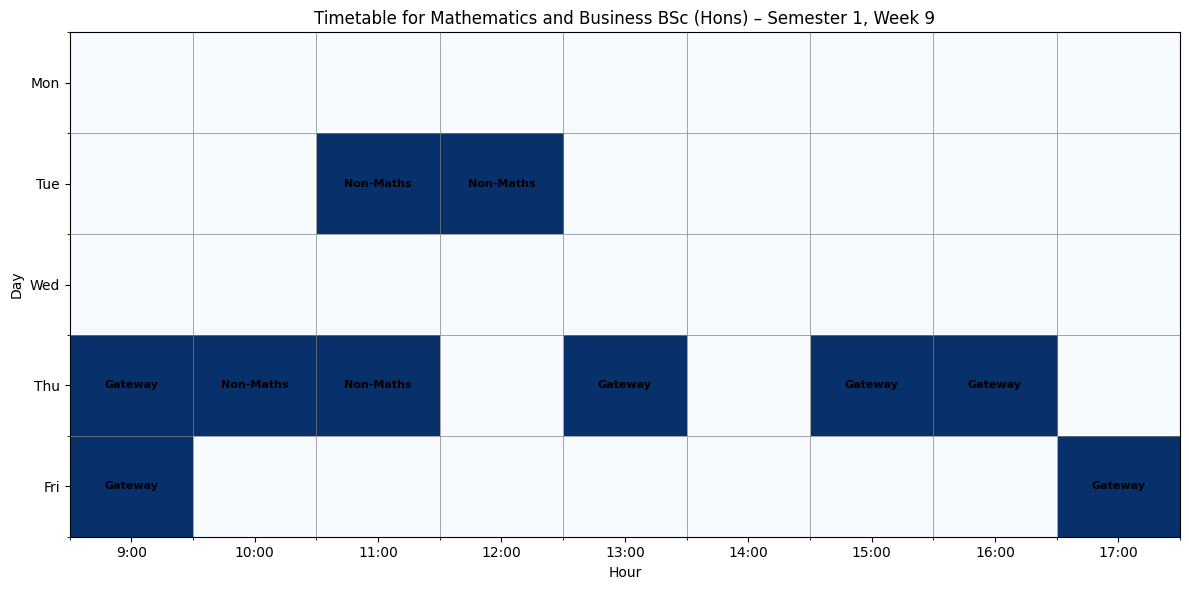

lin sol: {('G1', 1, 9, 1, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 9, 1, 'Mathematics and Business BSc (Hons)'): 0.0, ('G1', 1, 9, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 9, 2, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 9, 2, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 1, 'Economics and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 1, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 10, 1, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 2, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 10, 2, 'Mathema

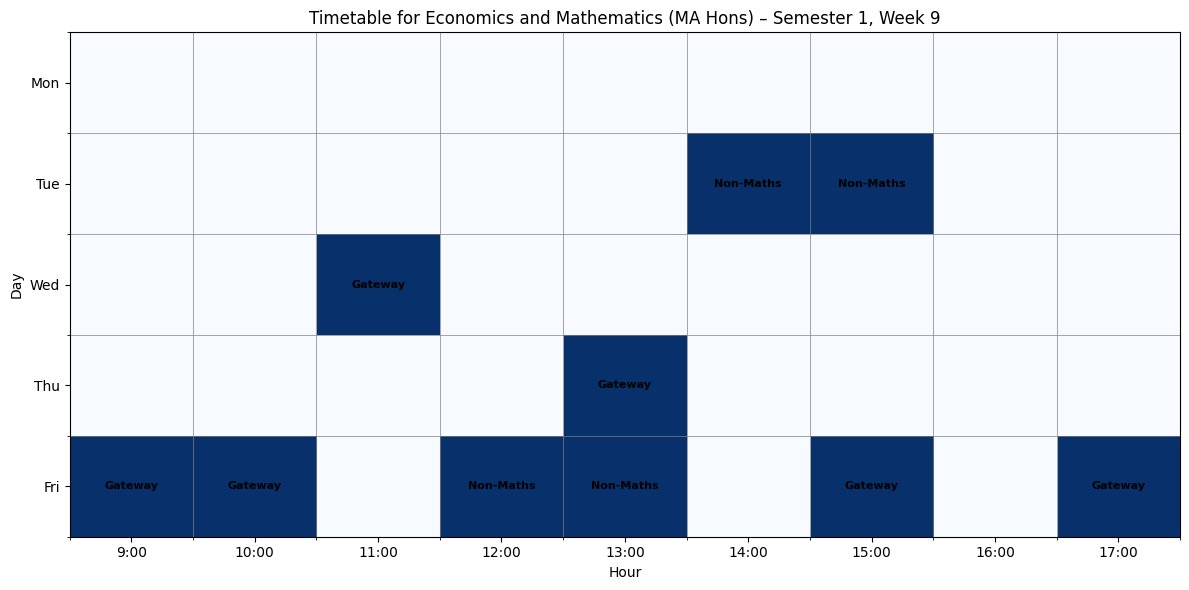

lin sol: {('G1', 1, 9, 1, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 9, 1, 'Mathematics and Business BSc (Hons)'): 0.0, ('G1', 1, 9, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 9, 2, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 9, 2, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 1, 'Economics and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 1, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 10, 1, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 2, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 10, 2, 'Mathema

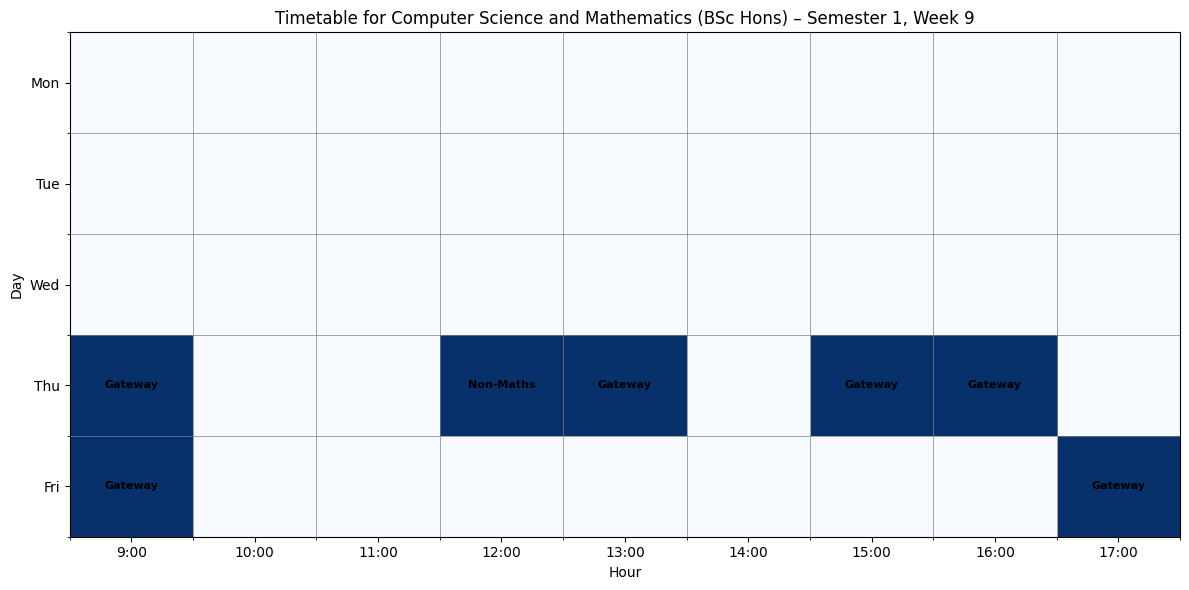

lin sol: {('G1', 1, 9, 1, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 9, 1, 'Mathematics and Business BSc (Hons)'): 0.0, ('G1', 1, 9, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 9, 2, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 9, 2, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 1, 'Economics and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 1, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 10, 1, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 2, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 10, 2, 'Mathema

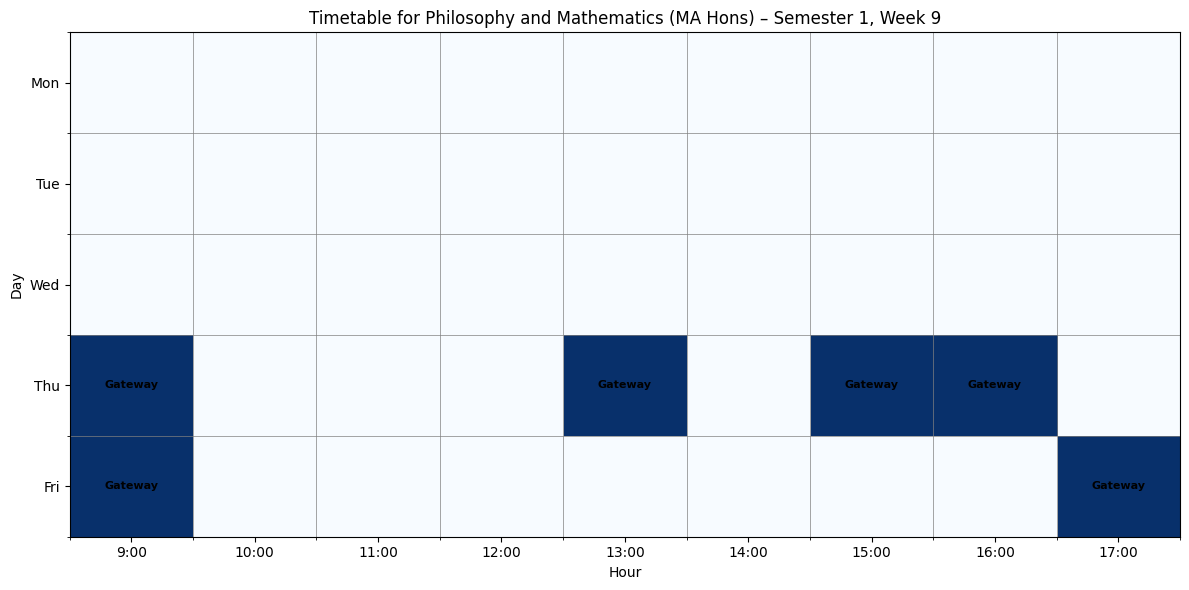

In [ ]:
programmes_needed = ['Mathematics and Business BSc (Hons)',
                     # 'Mathematics and Physics (BSc Hons)',
                     'Economics and Mathematics (MA Hons)','Computer Science and Mathematics (BSc Hons)',
              'Philosophy and Mathematics (MA Hons)']

for prog in programmes_needed:
    plot_curriculum_timetable(prog, semester = 1, var_sol = var_sol, parameters = parameters, week = 9)

lin sol: {('G1', 1, 9, 1, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 1, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 9, 1, 'Mathematics and Business BSc (Hons)'): 0.0, ('G1', 1, 9, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 9, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 9, 2, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 9, 2, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 1, 'Economics and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 1, 'Philosophy and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 1, 'Computer Science and Mathematics (BSc Hons)'): 0.0, ('G1', 1, 10, 1, 'Mathematics and Business BSc (Hons)'): -0.0, ('G1', 1, 10, 2, 'Economics and Mathematics (MA Hons)'): 0.0, ('G1', 1, 10, 2, 'Philosophy and Mathematics (MA Hons)'): -0.0, ('G1', 1, 10, 2, 'Computer Science and Mathematics (BSc Hons)'): -0.0, ('G1', 1, 10, 2, 'Mathema

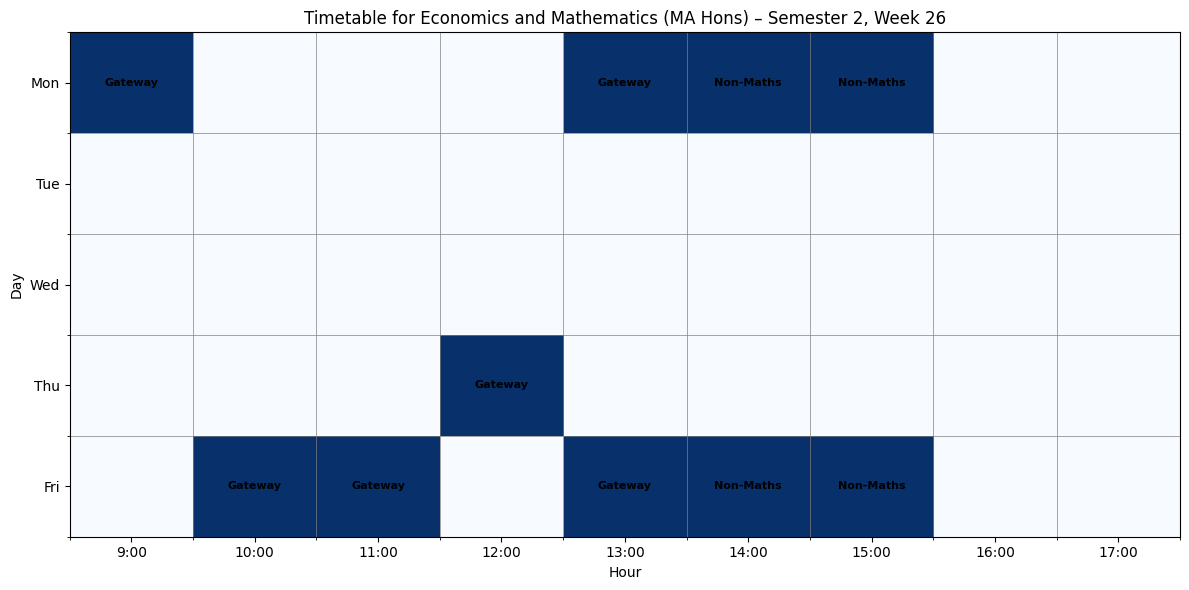

In [ ]:
# After solving and retrieving the solution dictionaries
# For example, for the 'Economics and Mathematics (MA Hons)' curriculum in Semester 1:
# 
plot_curriculum_timetable('Economics and Mathematics (MA Hons)', semester=2, 
                          var_sol=var_sol, parameters=parameters, week = 26)# 

# For all weeks combined:
#plot_curriculum_timetable('Economics and Mathematics (MA Hons)', semester=1, week=None)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_physics_timetable(courses_df, semester=1, week=None, 
                           day_names=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
                           hour_range=(9, 17),  # 9am to 5pm
                           figsize=(12, 6)):
    """
    Plot the timetable of physics courses.
    
    Parameters:
    - courses_df: DataFrame containing course event data (must have columns:
                  'Module Name', 'Module Department', 'Semester', 'Timeslot',
                  'Duration (minutes)', 'Weeks', 'Campus', etc.)
    - semester: 1 or 2 (default 1)
    - week: int (1-52) or None. If None, shows all weeks (color intensity = number of weeks the slot is occupied).
    - day_names: list of day labels (default Mon-Fri)
    - hour_range: tuple (start_hour, end_hour) in 24h format (default 9-17)
    - figsize: figure size
    """
    # Filter for physics courses
    physics_df = courses_df[courses_df['Module Department'] == 'School of Physics and Astronomy'].copy()
    
    if physics_df.empty:
        print("No physics courses found.")
        return
    
    # Parse timeslot and weeks
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to indices
    day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4,
               'Saturday':5, 'Sunday':6}
    
    # Create grid for hours
    hours = list(range(hour_range[0], hour_range[1]+1))
    n_hours = len(hours)
    n_days = len(day_names)
    
    # Initialize occupancy grid (days x hours)
    if week is None:
        # For all weeks, store count of weeks occupied
        occupancy = np.zeros((n_days, n_hours))
    else:
        # For a specific week, store binary occupancy
        occupancy = np.zeros((n_days, n_hours), dtype=bool)
    
    # Collect events to display labels (for specific week only)
    labels = [[[] for _ in hours] for _ in day_names]  # only if week is specific
    
    # For each physics course
    for _, row in physics_df.iterrows():
        # Check semester
        sem = row.get('Semester')
        if isinstance(sem, str):
            if sem == 'Semester 1':
                sem_num = 1
            elif sem == 'Semester 2':
                sem_num = 2
            else:
                continue
        else:
            sem_num = sem
        if sem_num != semester:
            continue
        
        # Parse timeslot
        day_str, hour = parse_timeslot(row['Timeslot'])
        if day_str is None or hour is None:
            continue
        if day_str not in day_map:
            continue
        day_idx = day_map[day_str]
        # Check hour within range
        if hour < hour_range[0] or hour > hour_range[1]:
            continue
        hour_idx = hour - hour_range[0]
        
        # Get weeks
        weeks = parse_weeks(row['Weeks'])
        if not weeks:
            continue
        # If week is specified, only consider that week
        if week is not None:
            if week not in weeks:
                continue
            occupancy[day_idx, hour_idx] = True
            # Add course name to labels
            labels[day_idx][hour_idx].append(row['Module Name'])
        else:
            # Count how many weeks this event covers
            occupancy[day_idx, hour_idx] += len(weeks)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if week is None:
        # Show occupancy as heatmap (number of weeks)
        im = ax.imshow(occupancy, cmap='YlOrRd', aspect='auto', 
                       vmin=0, vmax=occupancy.max() if occupancy.max() > 0 else 1)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of weeks occupied')
    else:
        # Show as binary occupied cells
        im = ax.imshow(occupancy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        # Add text labels
        for i in range(n_days):
            for j in range(n_hours):
                if occupancy[i, j]:
                    # Combine course names (if multiple)
                    courses_text = '\n'.join(labels[i][j])
                    ax.text(j, i, courses_text, ha='center', va='center',
                            fontsize=8, color='black', weight='bold')
    
    # Set axes
    ax.set_xticks(range(n_hours))
    ax.set_xticklabels([f'{h}:00' for h in hours])
    ax.set_yticks(range(n_days))
    ax.set_yticklabels(day_names)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Day')
    title = f"Physics Courses Timetable – Semester {semester}"
    if week:
        title += f", Week {week}"
    else:
        title += " (all weeks combined)"
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_hours, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_days, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot all physics courses in Semester 1 (all weeks combined)
plot_physics_timetable(courses_df, semester=1, week=None)

# Plot physics courses for Week 10 in Semester 1
plot_physics_timetable(courses_df, semester=1, week=10)

No physics courses found.
No physics courses found.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_compulsory_timetable(programme_name, programme_data, courses_df, 
                              semester=1, week=None,
                              day_names=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
                              hour_range=(9, 17),   # 9am to 5pm
                              figsize=(12, 6)):
    """
    Plot the timetable of compulsory courses for a given programme.
    
    Parameters:
    - programme_name: string (e.g., 'Mathematics and Physics (BSc Hons)')
    - programme_data: dictionary returned by extract_programme_structure()
    - courses_df: DataFrame containing course event data
    - semester: 1 or 2
    - week: int (1-52) or None. If None, shows all weeks (heatmap of occupancy count)
    - day_names: list of day labels
    - hour_range: tuple (start_hour, end_hour) in 24h format
    - figsize: figure size
    """
    # Get compulsory courses for the programme
    if programme_name not in programme_data:
        print(f"Programme '{programme_name}' not found in programme data.")
        return
    
    compulsory_courses = programme_data[programme_name]['compulsory_courses']
    if not compulsory_courses:
        print(f"No compulsory courses found for {programme_name}")
        return
    
    print(f"Compulsory courses for {programme_name}: {compulsory_courses}")
    
    # Filter timetable data for these courses
    relevant_df = courses_df[courses_df['Module Name'].isin(compulsory_courses)].copy()
    if relevant_df.empty:
        print("No timetable data found for these courses.")
        return
    
    # Parse timeslot and weeks
    def parse_timeslot(timeslot):
        if pd.isna(timeslot):
            return None, None
        parts = str(timeslot).split()
        if len(parts) >= 2:
            day = parts[0]
            time_str = parts[1]
            hour = int(time_str.split(':')[0])
            return day, hour
        return None, None
    
    def parse_weeks(weeks_str):
        if pd.isna(weeks_str):
            return []
        weeks = []
        for part in str(weeks_str).split(','):
            if '-' in part:
                start, end = map(int, part.split('-'))
                weeks.extend(range(start, end + 1))
            else:
                weeks.append(int(part))
        return weeks
    
    # Map days to indices
    day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4,
               'Saturday':5, 'Sunday':6}
    
    # Create grid
    hours = list(range(hour_range[0], hour_range[1]+1))
    n_hours = len(hours)
    n_days = len(day_names)
    
    # Initialize occupancy grid
    if week is None:
        occupancy = np.zeros((n_days, n_hours))   # count of weeks
    else:
        occupancy = np.zeros((n_days, n_hours), dtype=bool)
        labels = [[[] for _ in hours] for _ in day_names]
    
    # Process each row
    for _, row in relevant_df.iterrows():
        # Check semester
        sem = row.get('Semester')
        if isinstance(sem, str):
            if sem == 'Semester 1':
                sem_num = 1
            elif sem == 'Semester 2':
                sem_num = 2
            else:
                continue
        else:
            sem_num = sem
        if sem_num != semester:
            continue
        
        # Parse timeslot
        day_str, hour = parse_timeslot(row['Timeslot'])
        if day_str is None or hour is None:
            continue
        if day_str not in day_map:
            continue
        day_idx = day_map[day_str]
        if day_idx >= n_days:  # only show requested days
            continue
        if hour < hour_range[0] or hour > hour_range[1]:
            continue
        hour_idx = hour - hour_range[0]
        
        # Get weeks
        weeks = parse_weeks(row['Weeks'])
        if not weeks:
            continue
        
        if week is not None:
            if week in weeks:
                occupancy[day_idx, hour_idx] = True
                # Add course name to labels (maybe include course code as well)
                course_name = row['Module Name']
                labels[day_idx][hour_idx].append(course_name)
        else:
            occupancy[day_idx, hour_idx] += len(weeks)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    if week is None:
        im = ax.imshow(occupancy, cmap='YlOrRd', aspect='auto',
                       vmin=0, vmax=occupancy.max() if occupancy.max() > 0 else 1)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of weeks occupied')
    else:
        im = ax.imshow(occupancy, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        # Add text labels
        for i in range(n_days):
            for j in range(n_hours):
                if occupancy[i, j]:
                    # Combine course names
                    courses_text = '\n'.join(labels[i][j])
                    ax.text(j, i, courses_text, ha='center', va='center',
                            fontsize=8, color='black', weight='bold')
    
    # Set axes
    ax.set_xticks(range(n_hours))
    ax.set_xticklabels([f'{h}:00' for h in hours])
    ax.set_yticks(range(n_days))
    ax.set_yticklabels(day_names[:n_days])
    ax.set_xlabel('Hour')
    ax.set_ylabel('Day')
    title = f"Compulsory Courses – {programme_name} (Semester {semester})"
    if week:
        title += f", Week {week}"
    else:
        title += " (all weeks combined)"
    ax.set_title(title)
    
    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_hours, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_days, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot all weeks for Semester 1
plot_compulsory_timetable('Mathematics and Physics (BSc Hons)', 
                          programme_data, courses_df, 
                          semester=1, week=None)

# Plot a specific week (e.g., week 10)
plot_compulsory_timetable('Mathematics and Physics (BSc Hons)', 
                          programme_data, courses_df, 
                          semester=1, week=10)

Programme 'Mathematics and Physics (BSc Hons)' not found in programme data.
Programme 'Mathematics and Physics (BSc Hons)' not found in programme data.
